## Task 2: Feature Engineering, Model Optimization & Comparison

## Step 1: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Load the Dataset

In [4]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Separate Features and Target Variable

In [5]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

## Step 4: Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 5: Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Step 6: Train Multiple Models

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

## Step 7: Model Evaluation and Comparison

In [9]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


## Step 8: Visual Performance Validation

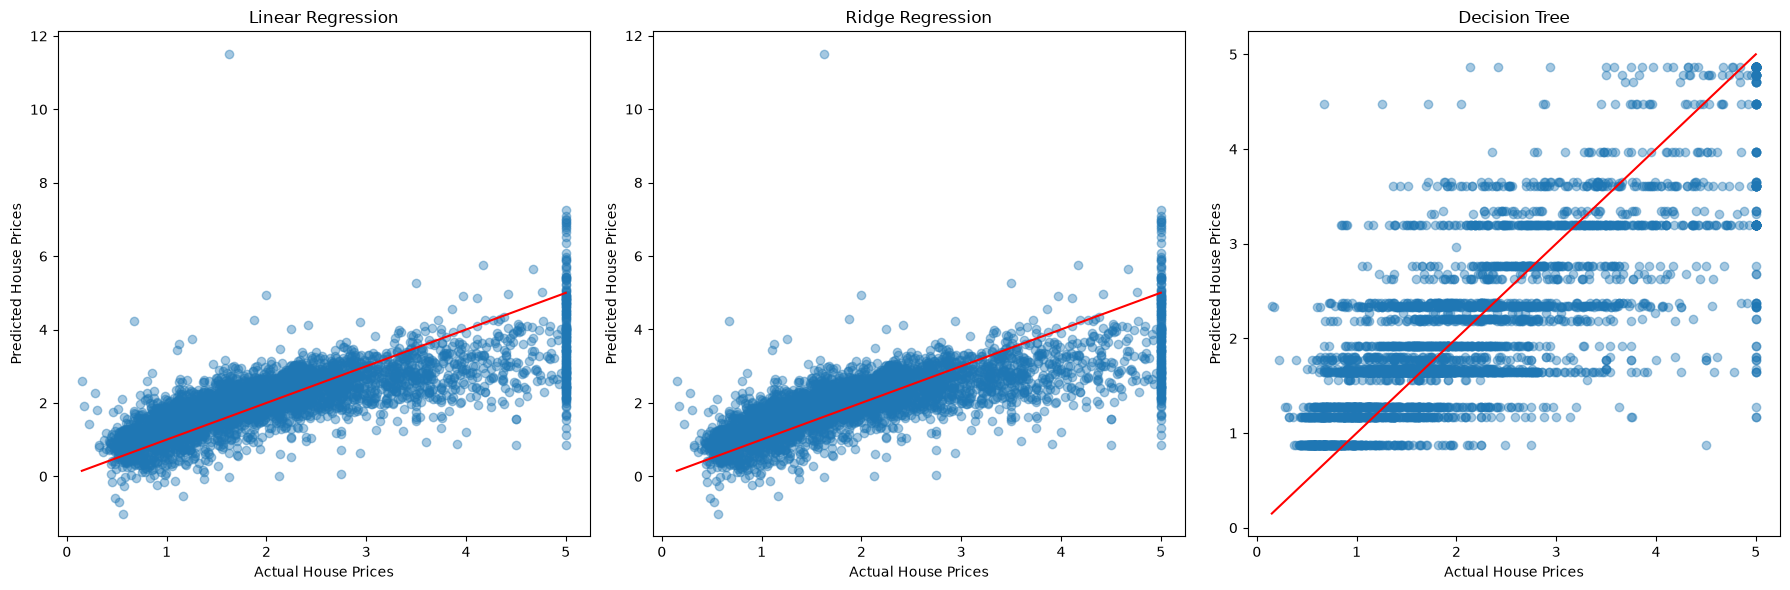

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.4)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="red")
    ax.set_xlabel("Actual House Prices")
    ax.set_ylabel("Predicted House Prices")
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Step 9: Additional Performance Insights

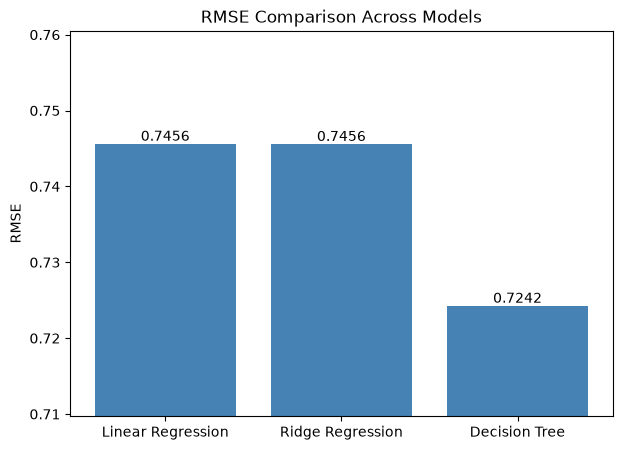

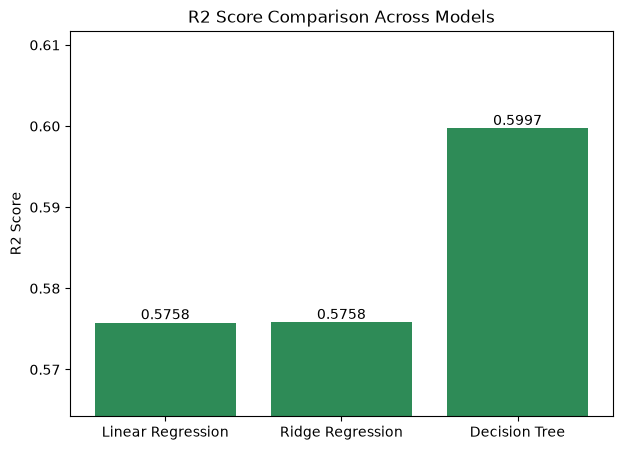

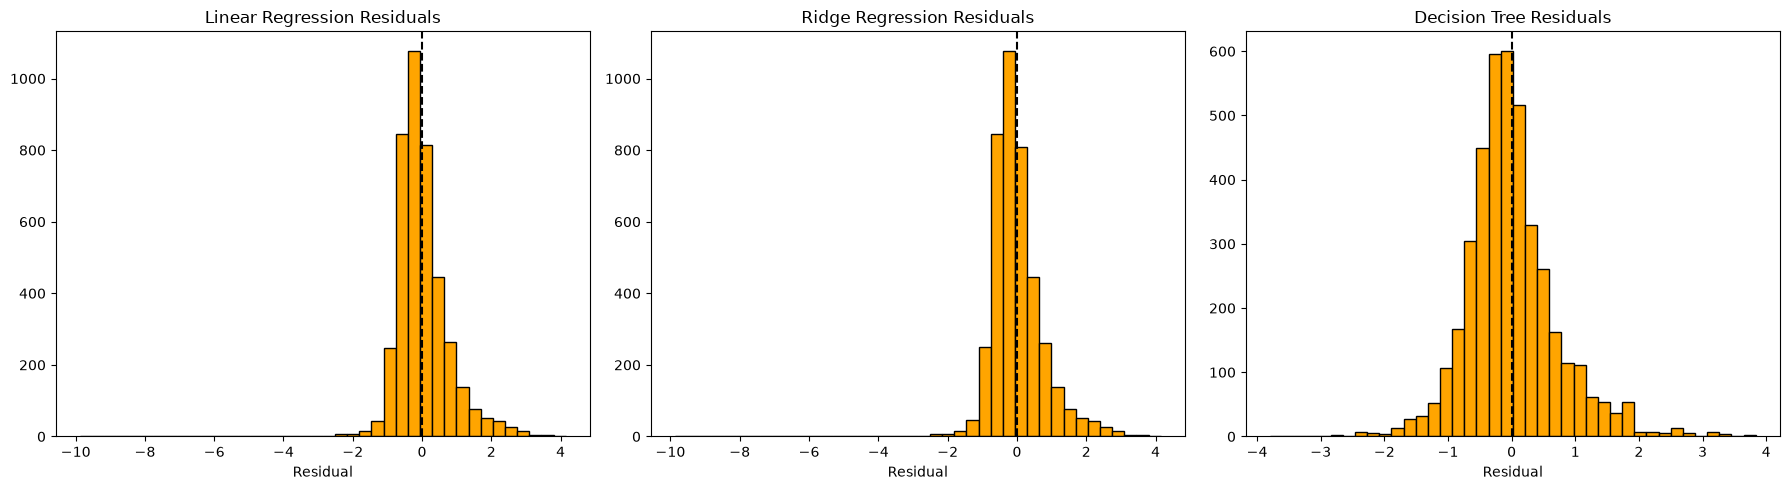

In [13]:
#RMSE
fig, ax = plt.subplots(figsize=(7,5))
rmse_vals = results_df["RMSE"]
ax.bar(rmse_vals.index, rmse_vals.values, color="steelblue")
ax.set_ylim(rmse_vals.min() * 0.98, rmse_vals.max() * 1.02)
for i, v in enumerate(rmse_vals.values):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison Across Models")
plt.show()

#R2
fig, ax = plt.subplots(figsize=(7,5))
r2_vals = results_df["R2 Score"]
ax.bar(r2_vals.index, r2_vals.values, color="seagreen")
ax.set_ylim(r2_vals.min() * 0.98, r2_vals.max() * 1.02)
for i, v in enumerate(r2_vals.values):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("R2 Score")
ax.set_title("R2 Score Comparison Across Models")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    resid = y_test - preds
    ax.hist(resid, bins=40, color="orange", edgecolor="black")
    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"{name} Residuals")
    ax.set_xlabel("Residual")
plt.tight_layout()
plt.show()